# Analysis

## Imports

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 200

## Load data

In [60]:
train1_path = '../datasets/train_part_1.parquet'
train2_path = '../datasets/train_part_2.parquet'
train3_path = '../datasets/train_part_3.parquet'
labels_path = '../datasets/train_labels.parquet'

train1_df = pd.read_parquet(train1_path)
train2_df = pd.read_parquet(train2_path)
train3_df = pd.read_parquet(train3_path)
labels_df = pd.read_parquet(labels_path)

## Preprocess

#### Проверим размеры датасетов:

In [61]:
print(f"train1_df: {train1_df.shape}")
print(f"train1_df: {train2_df.shape}")
print(f"train1_df: {train3_df.shape}")
print(f"labels_df: {labels_df.shape}")

train1_df: (28618594, 23)
train1_df: (28558397, 23)
train1_df: (28500849, 23)
labels_df: (87514, 3)


#### Проверим колонки датасетов и их типы данных:

In [62]:
print("train1_df:")
for col in train1_df.columns:
    print(f"- {col}: {train1_df[col].dtype}")

print("\nlabels_df:")
for col in labels_df.columns:
    print(f"- {col}: {labels_df[col].dtype}")

train1_df:
- customer_id: int64
- event_id: int64
- event_dttm: str
- event_type_nm: int32
- event_desc: int32
- channel_indicator_type: int32
- channel_indicator_sub_type: int32
- operaton_amt: float64
- currency_iso_cd: float64
- mcc_code: str
- pos_cd: float64
- accept_language: str
- browser_language: str
- timezone: float64
- session_id: float64
- operating_system_type: float64
- battery: str
- device_system_version: str
- screen_size: str
- developer_tools: str
- phone_voip_call_state: float64
- web_rdp_connection: float64
- compromised: str

labels_df:
- customer_id: int64
- event_id: int64
- target: int32


#### Добавляем в датасеты признаков разметку по классам:

In [63]:
train1_df = pd.merge(train1_df, labels_df, on=['customer_id', 'event_id'], how='left')
train2_df = pd.merge(train2_df, labels_df, on=['customer_id', 'event_id'], how='left')
train3_df = pd.merge(train3_df, labels_df, on=['customer_id', 'event_id'], how='left')

In [64]:
print(train1_df['target'])

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
            ..
28618589   NaN
28618590   NaN
28618591   NaN
28618592   NaN
28618593   NaN
Name: target, Length: 28618594, dtype: float64


#### Заменяем пропущенные значения ("чистые" операции ранее имели NaN-значение):

In [65]:
train1_df['target'] = train1_df['target'].fillna(-1)
print(train1_df['target'])

0          -1.000
1          -1.000
2          -1.000
3          -1.000
4          -1.000
            ...  
28618589   -1.000
28618590   -1.000
28618591   -1.000
28618592   -1.000
28618593   -1.000
Name: target, Length: 28618594, dtype: float64


## Research 

#### Посмотрим, какое значение для анализа имеет каждый из признаков:

**Идентификационные данные**

`customer_id` - ID клиента  
`event_id` - ID операции  
`session_id` - ID сессии

Зачем: Позволяют выявлять аномальное поведение конкретного клиента или множественные операции в одной сессии

**Временные метки**

`event_dttm` - дата и время операции

Зачем: Фрод часто происходит в нерабочее время (ночью, в праздники)

**Типы операций**

`event_type_nm` - тип операции (например, покупка, перевод, снятие)  
`event_desc` - описание операции

Зачем: Некоторые типы операций более рискованны (например, крупные переводы)

**Каналы и устройства, с которых производится транзакция**

`channel_indicator_type` - тип канала (мобильное приложение, веб, терминал)  
`channel_indicator_sub_type` - подтип канала  
`operating_system_type` - ОС устройства  
`device_system_version` - версия ОС  
`screen_size` - размер экрана  
`battery` - уровень заряда батареи  
`phone_voip_call_state` - состояние VoIP звонка  
`browser_language` - язык браузера  
`accept_language` - Accept-Language заголовок  
`timezone` - часовой пояс  

Зачем:
* Несоответствие языка/часового пояса местоположению клиента
* Эмуляторы имеют специфические размеры экрана, уровень батареи (часто 100% или -1)
* VoIP состояние может указывать на подмену номера

**Финансовые данные**

`operaton_amt` - сумма операции  
`currency_iso_cd` - валюта

Зачем: Необычно крупные суммы, несоответствие валюты региону

**Геолокационные и торговые**

`mcc_code` - Merchant Category Code (код категории торговца)  
`pos_cd` - код точки продажи

Зачем: Подозрительные категории (казино, криптобиржи), несоответствие обычным паттернам покупок

**Технические признаки безопасности**

`developer_tools` - включены ли инструменты разработчика  
`web_rdp_connection` - подключение через RDP  
`compromised` - метка, что устройство/сессия скомпрометированы

Зачем:
* developer_tools = 1: попытка отладки/взлома
* web_rdp_connection = 1: удаленный доступ (частый признак мошенников)
* compromised = 1: уже известное скомпрометированное устройство

#### Проанализируем target:

Колонка `target` имеет значения 1, 0 и -1. Нам известно, что -1 - это самый часто встречающийся класс = "чистые" операции; два других означают подозрительные операции.

В задании указано, что **целевой класс, "красный свет" - это непотвержденные операции, класс 1.**  
Это означает, что когда банк зафиксировал подозрительную операцию, то связался с клиентом и задал вопрос "Это вы совершили операцию?" и клиент ответил "Нет, это не я".  
**Это и является фродом.**

Также имеется **"желтый свет"** - операции, подтвержденные клиентом - класс 0.  
Это означает, что когда банк зафиксировал подозрительную операцию, то клиент в ответ на вопрос банка подтвердил, что он сам совершил эту операцию.  
Это не целевой класс, не является фродом. Но он также может содержать выбросы по суммам или другие нетипичные значения в признаках.

Посмотрим "подозрительные" значения в обоих классах:

In [66]:
for val in [0, 1]:
    subset = train1_df[train1_df['target'] == val]
    print(f"Класс {val} (n = {len(subset)})")
    
    rdp_pct = subset['web_rdp_connection'].mean() * 100
    print(f"RDP: {rdp_pct:.2f}%")
    
    if 'developer_tools' in subset.columns:
        dev_tools_numeric = pd.to_numeric(subset['developer_tools'], errors='coerce')
        dev_pct = dev_tools_numeric.mean() * 100
        print(f"Developer tools: {dev_pct:.2f}%")

    if 'compromised' in subset.columns:
        comp_numeric = pd.to_numeric(subset['compromised'], errors='coerce')
        comp_pct = comp_numeric.mean() * 100
        print(f"Compromised: {comp_pct:.2f}%")
    
    print(f"Средняя сумма: {subset['operaton_amt'].mean():.0f}")
    print(f"Медианная сумма: {subset['operaton_amt'].median():.0f}")
    print(f"Максимальная сумма: {subset['operaton_amt'].max():.0f}\n")

Класс 0 (n = 12082)
RDP: 6.56%
Developer tools: 17.03%
Compromised: 0.17%
Средняя сумма: 22885937
Медианная сумма: 1010000
Максимальная сумма: 12762880000

Класс 1 (n = 17384)
RDP: 1.82%
Developer tools: 15.79%
Compromised: 0.03%
Средняя сумма: 7042597
Медианная сумма: 362916
Максимальная сумма: 1150380064



#### Значения для сабмита:

В примерах значений для сабмита есть числа типа -4, т.е. не вероятность (которая может быть только от 0 до 1).  

Это линейная комбинация весов признаков (буквально сумма значений признаков, умноженных на их веса, плюс сдвиг). Чем это значение меньше, тем ниже вероятность фрода, и наоборот.  
Это называется raw score (сырой скор), который легко конвертируется в вероятность и может быть получен в некоторых моделях напрямую вместо вероятности.

Например, в catboost:

`submission['predict'] = model.predict(X_test, prediction_type='RawFormulaVal')`

#### Распределение операций по времени суток:

Чистые, n = 28589128):
  День (8-18): 70.0%
  Вечер (19-23): 2.2%
  Ночь (0-4): 15.1%
  Утро (5-7): 12.7%

Подозр. подтв., n = 12082):
  День (8-18): 69.8%
  Вечер (19-23): 1.8%
  Ночь (0-4): 13.9%
  Утро (5-7): 14.4%

Фрод, n = 17384):
  День (8-18): 73.6%
  Вечер (19-23): 4.8%
  Ночь (0-4): 11.4%
  Утро (5-7): 10.2%



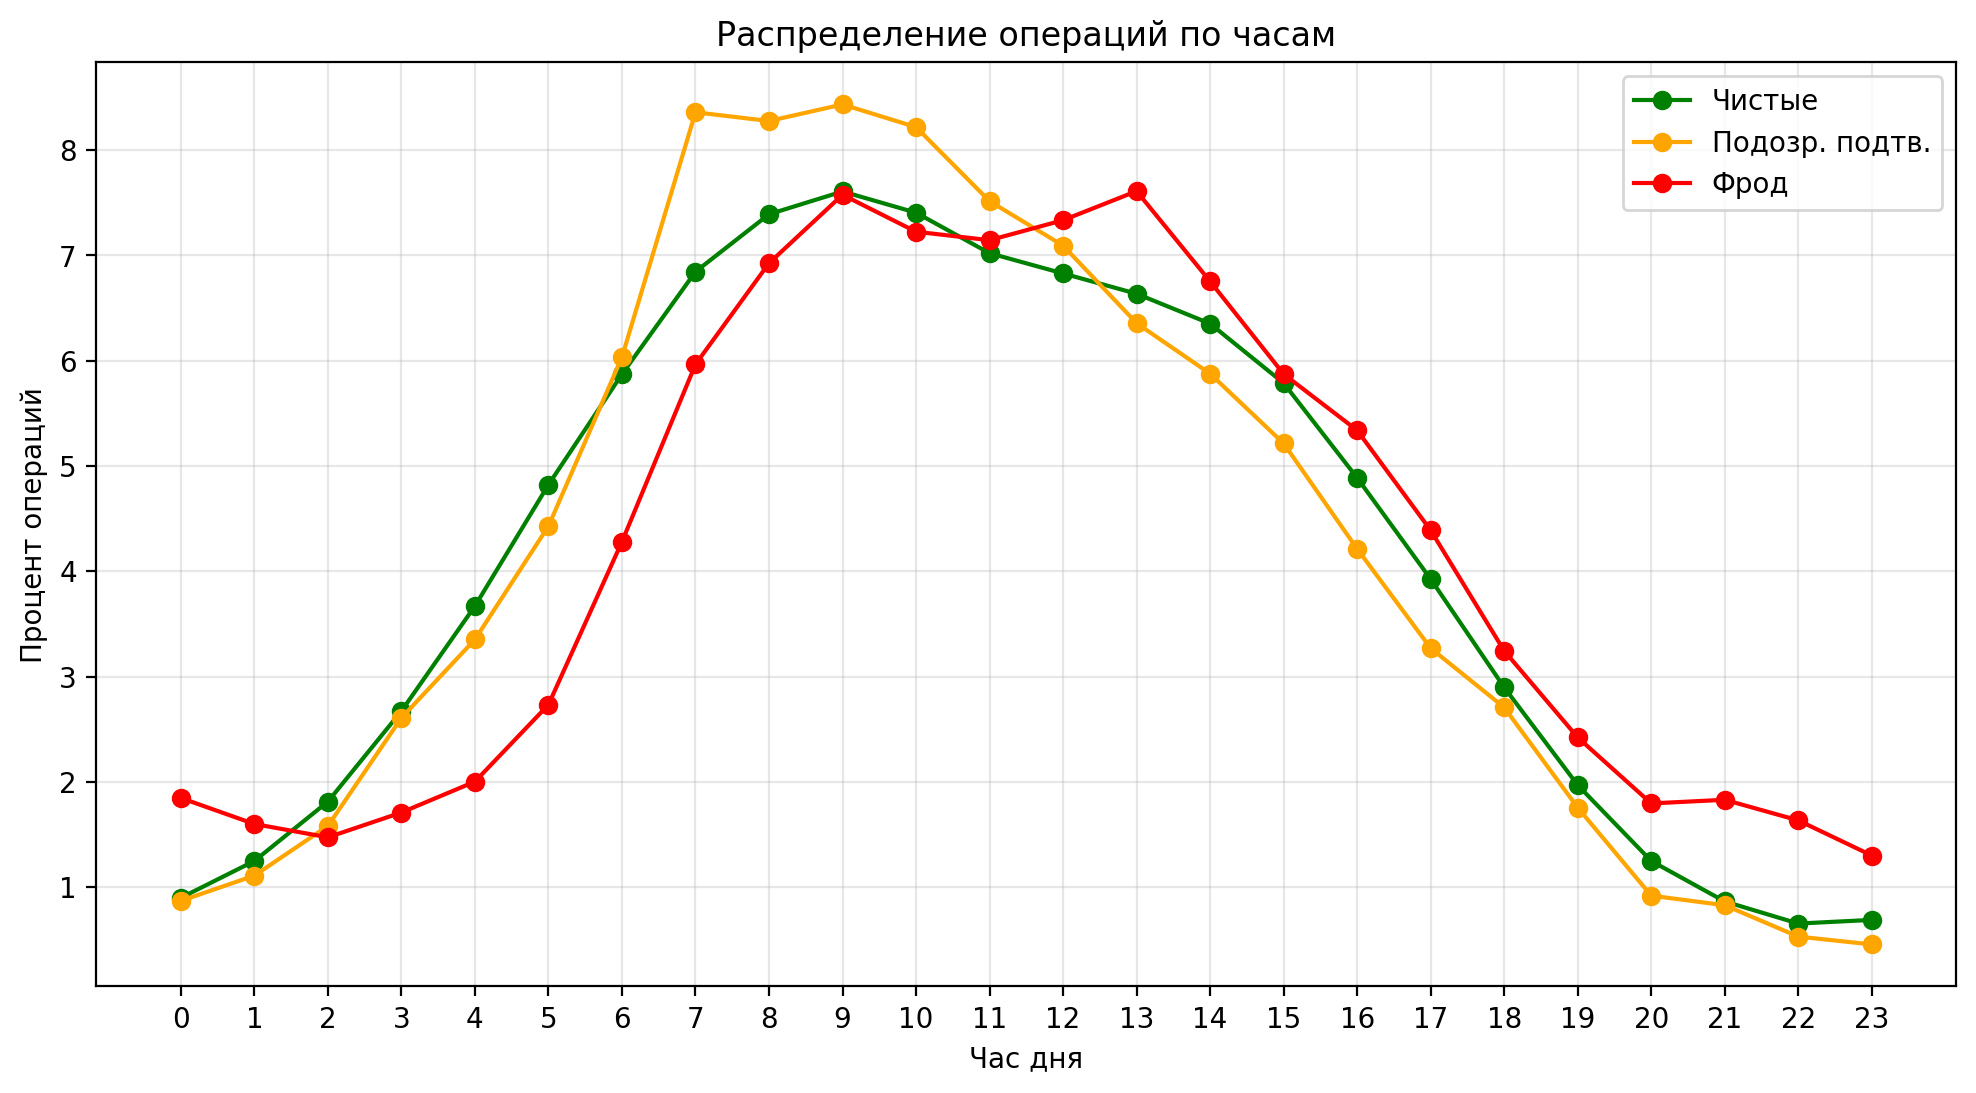

In [67]:
df_time = train1_df.copy()
df_time['event_dttm'] = pd.to_datetime(df_time['event_dttm'])
df_time['hour'] = df_time['event_dttm'].dt.hour
df_time['day_of_week'] = df_time['event_dttm'].dt.dayofweek
df_time['is_weekend'] = df_time['day_of_week'].isin([5, 6]).astype(int)
df_time['month'] = df_time['event_dttm'].dt.month
df_time['day_of_month'] = df_time['event_dttm'].dt.day

hourly_dist = {}
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = (hourly / len(subset) * 100).round(2)
    hourly_dist[name] = hourly_pct
    
    print(f"{name}, n = {len(subset)}):")
    
    day_pct = (subset['hour'].between(8, 20)).mean() * 100
    night_pct = (subset['hour'].between(0, 5)).mean() * 100
    morning_pct = (subset['hour'].between(6, 7)).mean() * 100
    evening_pct = (subset['hour'].between(21, 23)).mean() * 100
    
    print(f"  День (8-18): {day_pct:.1f}%")
    print(f"  Вечер (19-23): {evening_pct:.1f}%")
    print(f"  Ночь (0-4): {night_pct:.1f}%")
    print(f"  Утро (5-7): {morning_pct:.1f}%\n")
    
fraud = df_time[df_time['target'] == 1]
fraud_hourly = fraud['hour'].value_counts().sort_index()
fraud_hourly_pct = fraud_hourly / len(fraud) * 100

plt.figure(figsize=(12, 6))

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = hourly / len(subset) * 100
    plt.plot(hourly_pct.index, hourly_pct.values, marker='o', label=name, color=color)

plt.xlabel('Час дня')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.show()

Видим, что нет четкой зависимости вида операций от времени суток (фрод НЕ совершается чаще ночью и т.п.)

#### Распределение операций по дням недели:

Операции в выходные:
  Чистые: 24.2%
  Подозр. подтв.: 18.9%
  Фрод: 21.6%

Операции в праздники:
  Чистые: 3.6%
  Подозр. подтв.: 2.1%
  Фрод: 3.3%


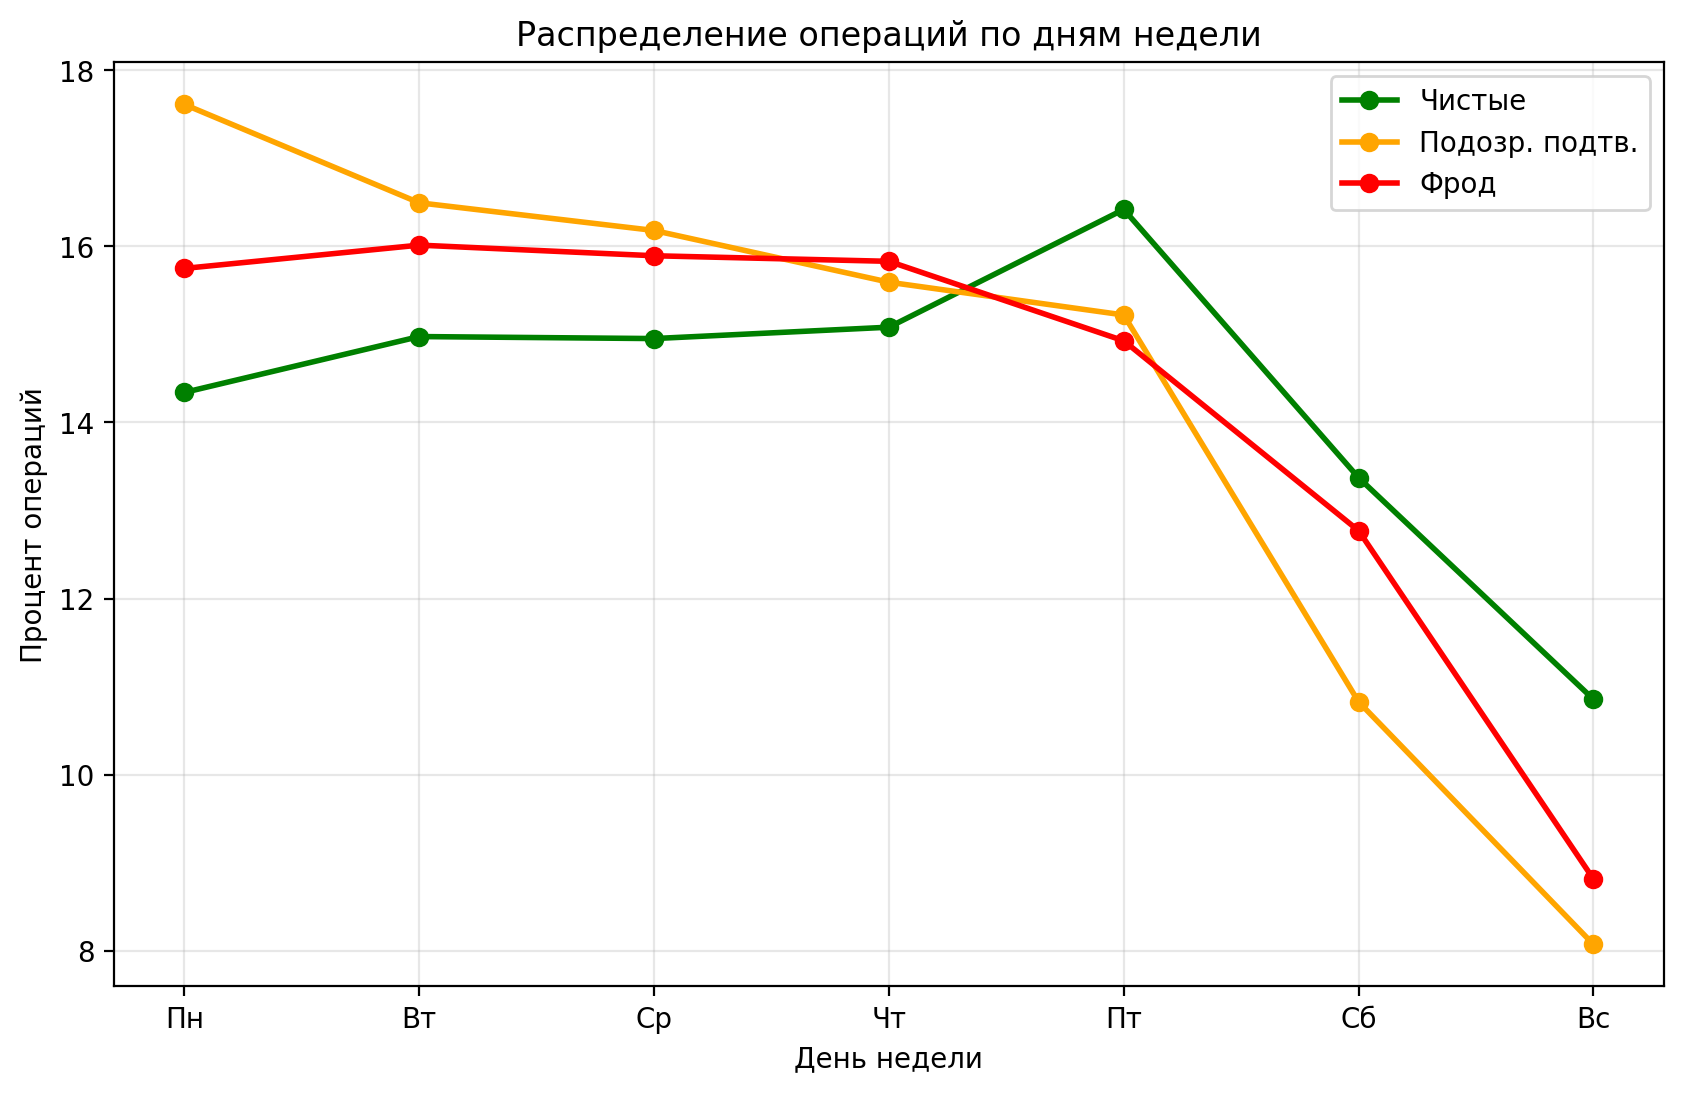

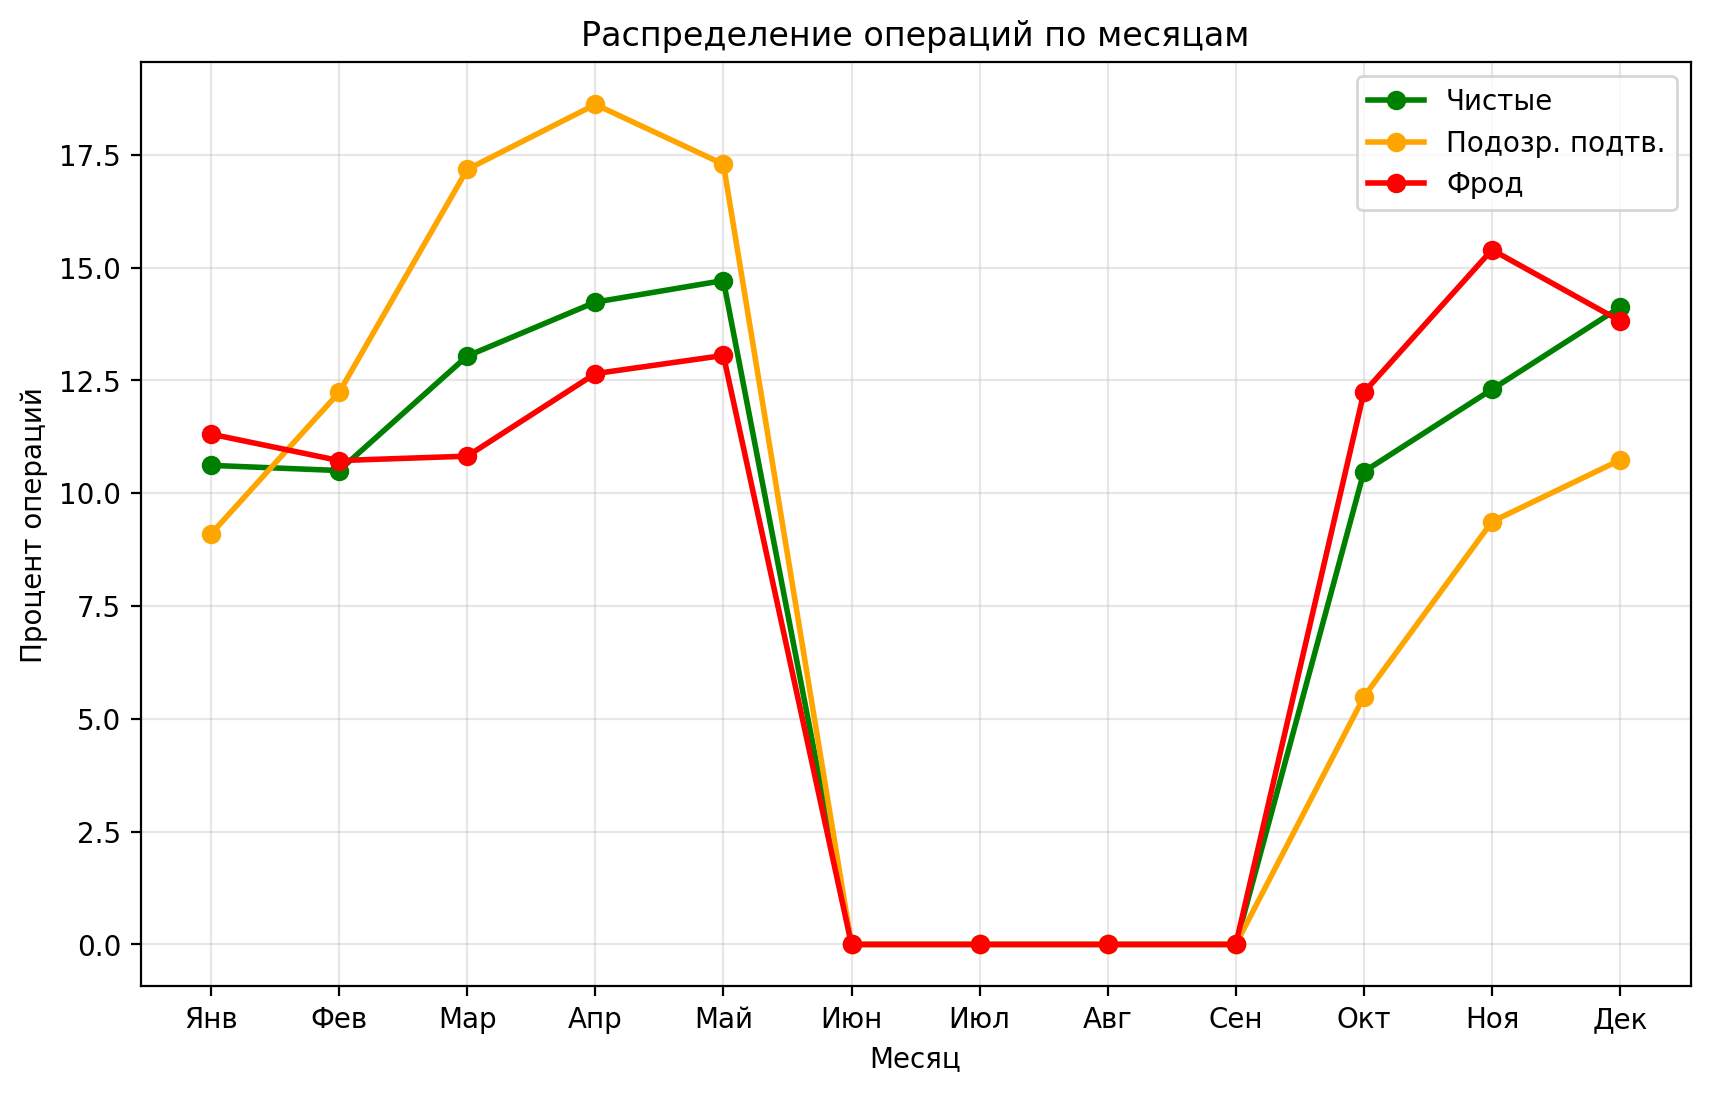

In [68]:
russian_holidays = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7),
    (2, 23),
    (3, 8),
    (5, 1), (5, 9),
    (6, 12),
    (11, 4),
]

df_time['is_holiday'] = df_time.apply(
    lambda row: (row['month'], row['day_of_month']) in russian_holidays, 
    axis=1
).astype(int)

print("Операции в выходные:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    weekend_pct = subset['is_weekend'].mean() * 100
    print(f"  {name}: {weekend_pct:.1f}%")

print("\nОперации в праздники:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    holiday_pct = subset['is_holiday'].mean() * 100
    print(f"  {name}: {holiday_pct:.1f}%")

plt.figure(figsize=(10, 6))

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    dow_dist = subset['day_of_week'].value_counts().sort_index()
    dow_pct = (dow_dist / len(subset) * 100).reindex(range(7), fill_value=0)
    plt.plot(days, dow_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('День недели')
plt.ylabel('Процент операций')
plt.title('Распределение операций по дням недели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    month_dist = subset['month'].value_counts().sort_index()
    month_pct = (month_dist / len(subset) * 100).reindex(range(1, 13), fill_value=0)
    plt.plot(months, month_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Месяц')
plt.ylabel('Процент операций')
plt.title('Распределение операций по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Распределение операций по часовым поясам:


Чистые (n=28589128):
  TZ 31: 1747434 оп. (63.6%)
  TZ 13: 338867 оп. (12.3%)
  TZ 21: 81005 оп. (2.9%)
  TZ 27: 76606 оп. (2.8%)
  TZ 16: 63038 оп. (2.3%)

Подозр./подтв. (n=12082):
  TZ 31: 1143 оп. (66.5%)
  TZ 13: 187 оп. (10.9%)
  TZ 27: 60 оп. (3.5%)
  TZ 21: 60 оп. (3.5%)
  TZ 16: 45 оп. (2.6%)

Фрод (n=17384):
  TZ 31: 716 оп. (60.6%)
  TZ 13: 108 оп. (9.1%)
  TZ 27: 61 оп. (5.2%)
  TZ 33: 50 оп. (4.2%)
  TZ 20: 34 оп. (2.9%)


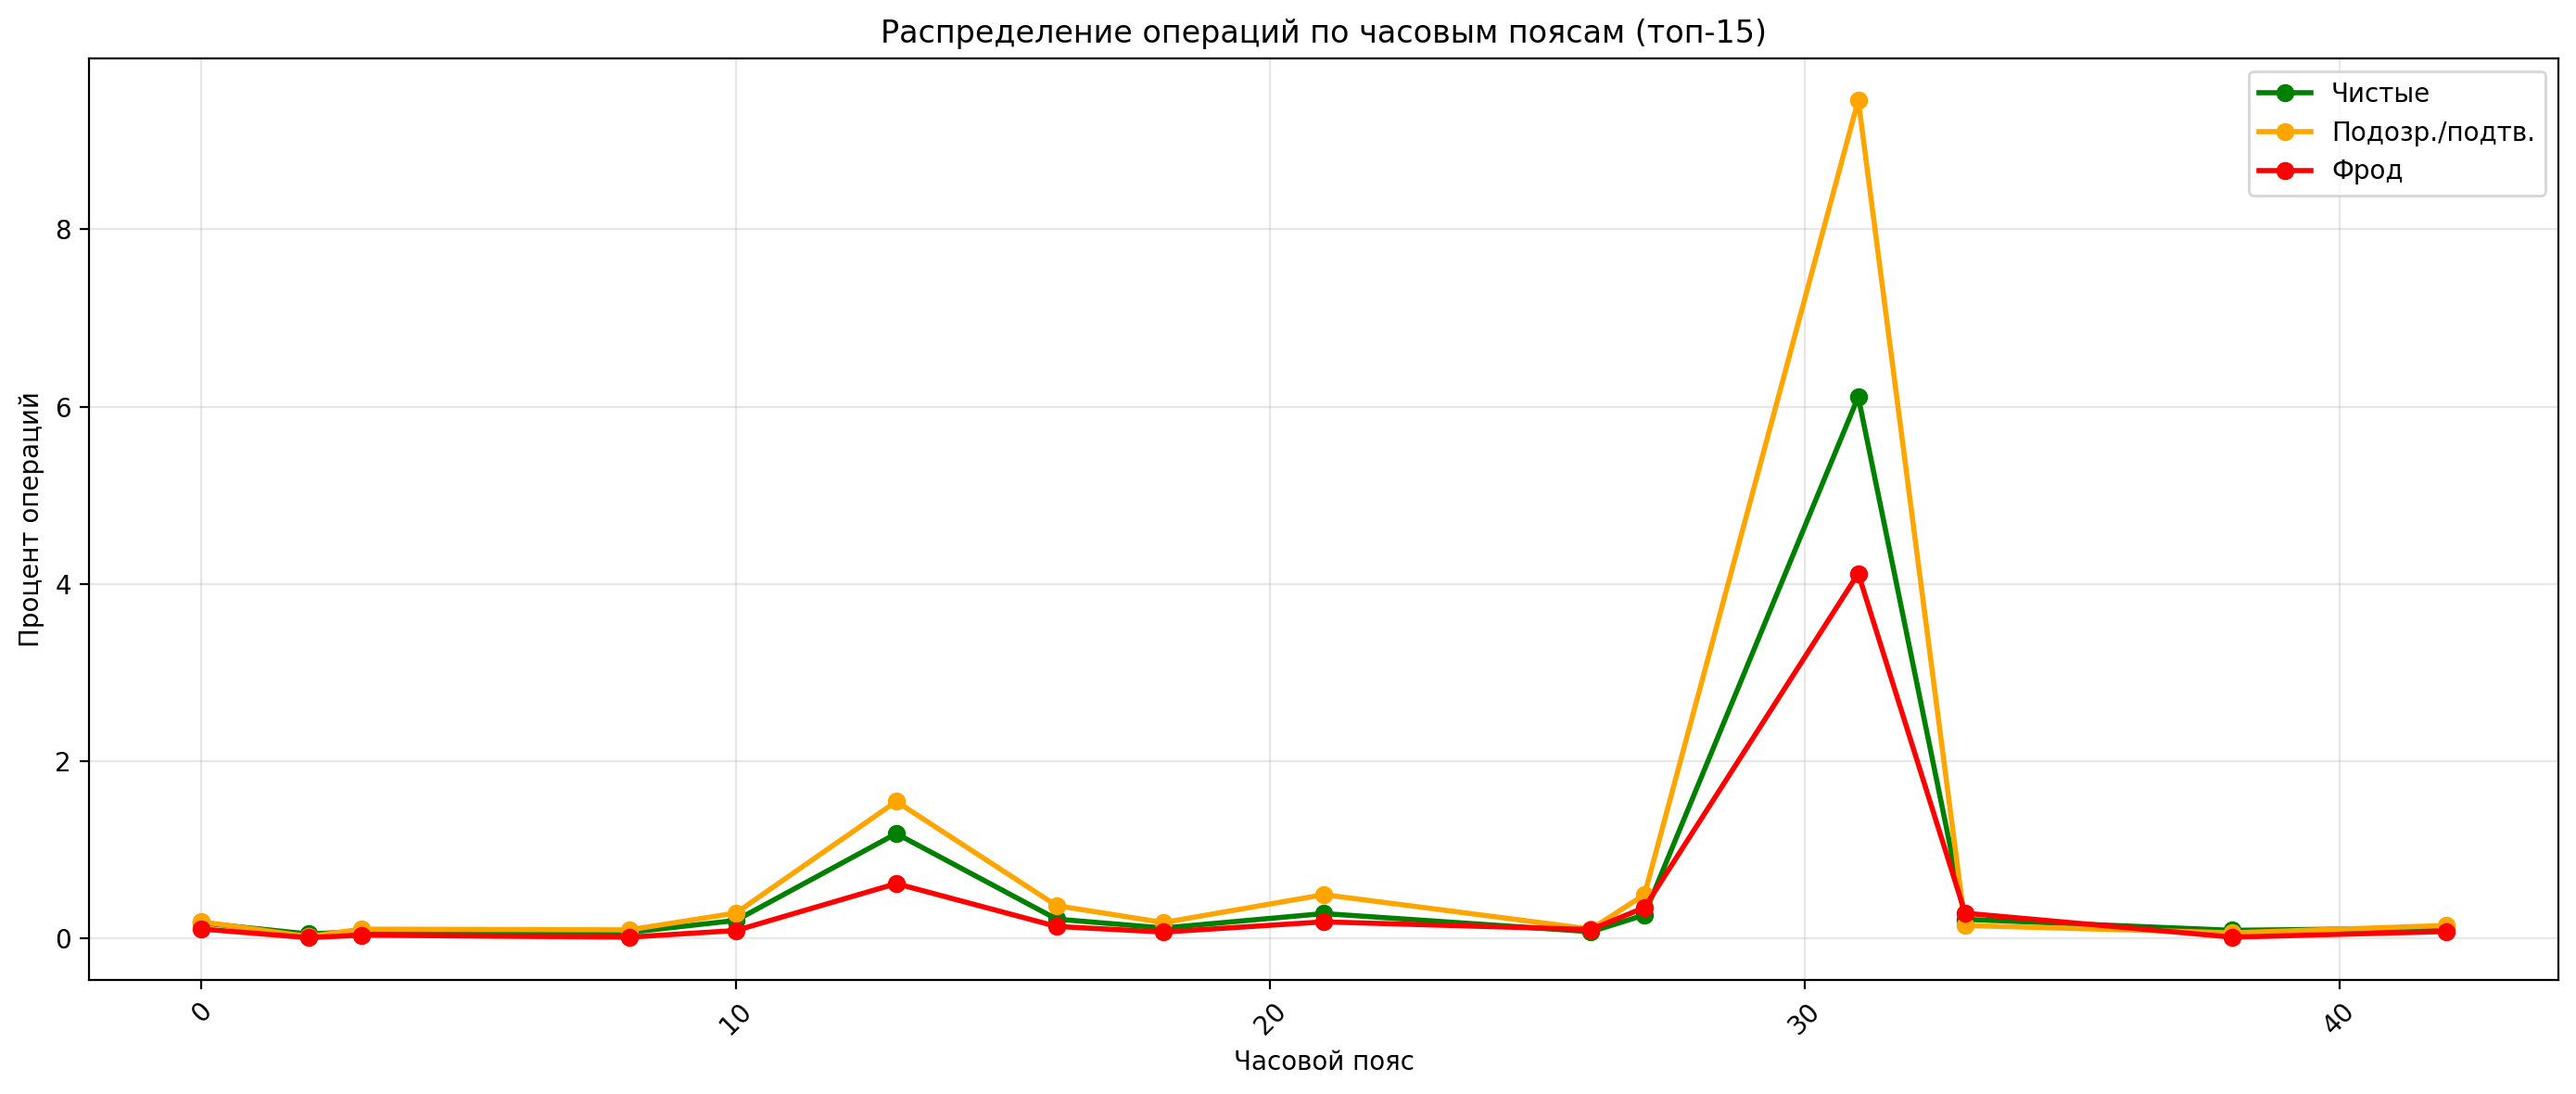

In [69]:
df_geo = train1_df.copy()

for val, name in [(-1, 'Чистые'), (0, 'Подозр./подтв.'), (1, 'Фрод')]:
    subset = df_geo[df_geo['target'] == val]
    print(f"\n{name} (n={len(subset)}):")
    
    # Топ-5 часовых поясов
    top_tz = subset['timezone'].value_counts().head(5)
    top_tz_pct = subset['timezone'].value_counts(normalize=True).head(5) * 100
    
    for tz, count in top_tz.items():
        pct = top_tz_pct[tz]
        print(f"  TZ {tz:.0f}: {count} оп. ({pct:.1f}%)")

plt.figure(figsize=(14, 6))

top15_tz = df_geo['timezone'].value_counts().head(15).sort_index()

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр./подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_geo[df_geo['target'] == val]

    tz_dist = subset['timezone'].value_counts()
    tz_dist_pct = (tz_dist / len(subset) * 100)
    tz_dist_pct = tz_dist_pct.reindex(top15_tz.index, fill_value=0)
    
    plt.plot(tz_dist_pct.index, tz_dist_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Часовой пояс')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часовым поясам (топ-15)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Анализ существующих признаков для предобработки:

#### battery

In [70]:
battery_vals = train1_df['battery'].unique()
print(f"Всего уникальных значений батареи: {len(battery_vals)}")

for i, val in enumerate(battery_vals):
    val_str = str(val)[:100]
    print(f"{val_str}")

Всего уникальных значений батареи: 118
nan
not available
93%
100%
76%
73%
69%
55.00000000000001%
54%
53%
61%
56.00000000000001%
42%
87%
51%
43%
98%
59%
6%
77%
99%
80%
89%
30%
96%
36%
62%
72%
47%
46%
79%
82%
78%
52%
22%
4%
85%
49%
71%
92%
94%
97%
18%
63%
81%
84%
64%
39%
66%
33%
90%
28.000000000000004%
60%
40%
32%
20%
34%
70%
38%
48%
74%
86%
41%
67%
14.000000000000002%
57.99999999999999%
25%
35%
50%
95%
44%
9%
17%
45%
65%
68%
91%
83%
75%
12%
27%
16%
28.999999999999996%
23%
19%
37%
21%
56.99999999999999%
88%
26%
24%
8%
11%
10%
0%
15%
31%
1%
2%
5%
3%
13%
NaN%
7.000000000000001%
:0%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chro
:100%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Ch
:100%,User-Agent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Ch
:100%,reducedMotion:false,mouseTimingV1:[],userAgent:Mozilla/5.0 (Windows NT 10.0; Win64; x64) Apple
:100%,User-Agen

Видим, что в колонке батареи есть как разные проценты, так и NaN-значения, и non available, и мусорные значения. Посмотрим их распределение.

  Проценты: 348427 (1.2174846885%)
  not available: 2301709 (8.0427046835%)
  NaN (пропуски): 25968432 (90.7397197780%)
  Мусор (длинные строки): 26 (0.0000908500%)

Чистые (n = 28589128):
  Проценты: 1.22%
  not available: 8.04%
  NaN (пропуски): 90.74%
  Мусор (длинные строки): 0.00%

Подозр. подтв. (n = 12082):
  Проценты: 2.57%
  not available: 11.54%
  NaN (пропуски): 85.90%
  Мусор (длинные строки): 0.0000000000%

Фрод (n = 17384):
  Проценты: 2.23%
  not available: 4.35%
  NaN (пропуски): 93.42%
  Мусор (длинные строки): 0.0000000000%


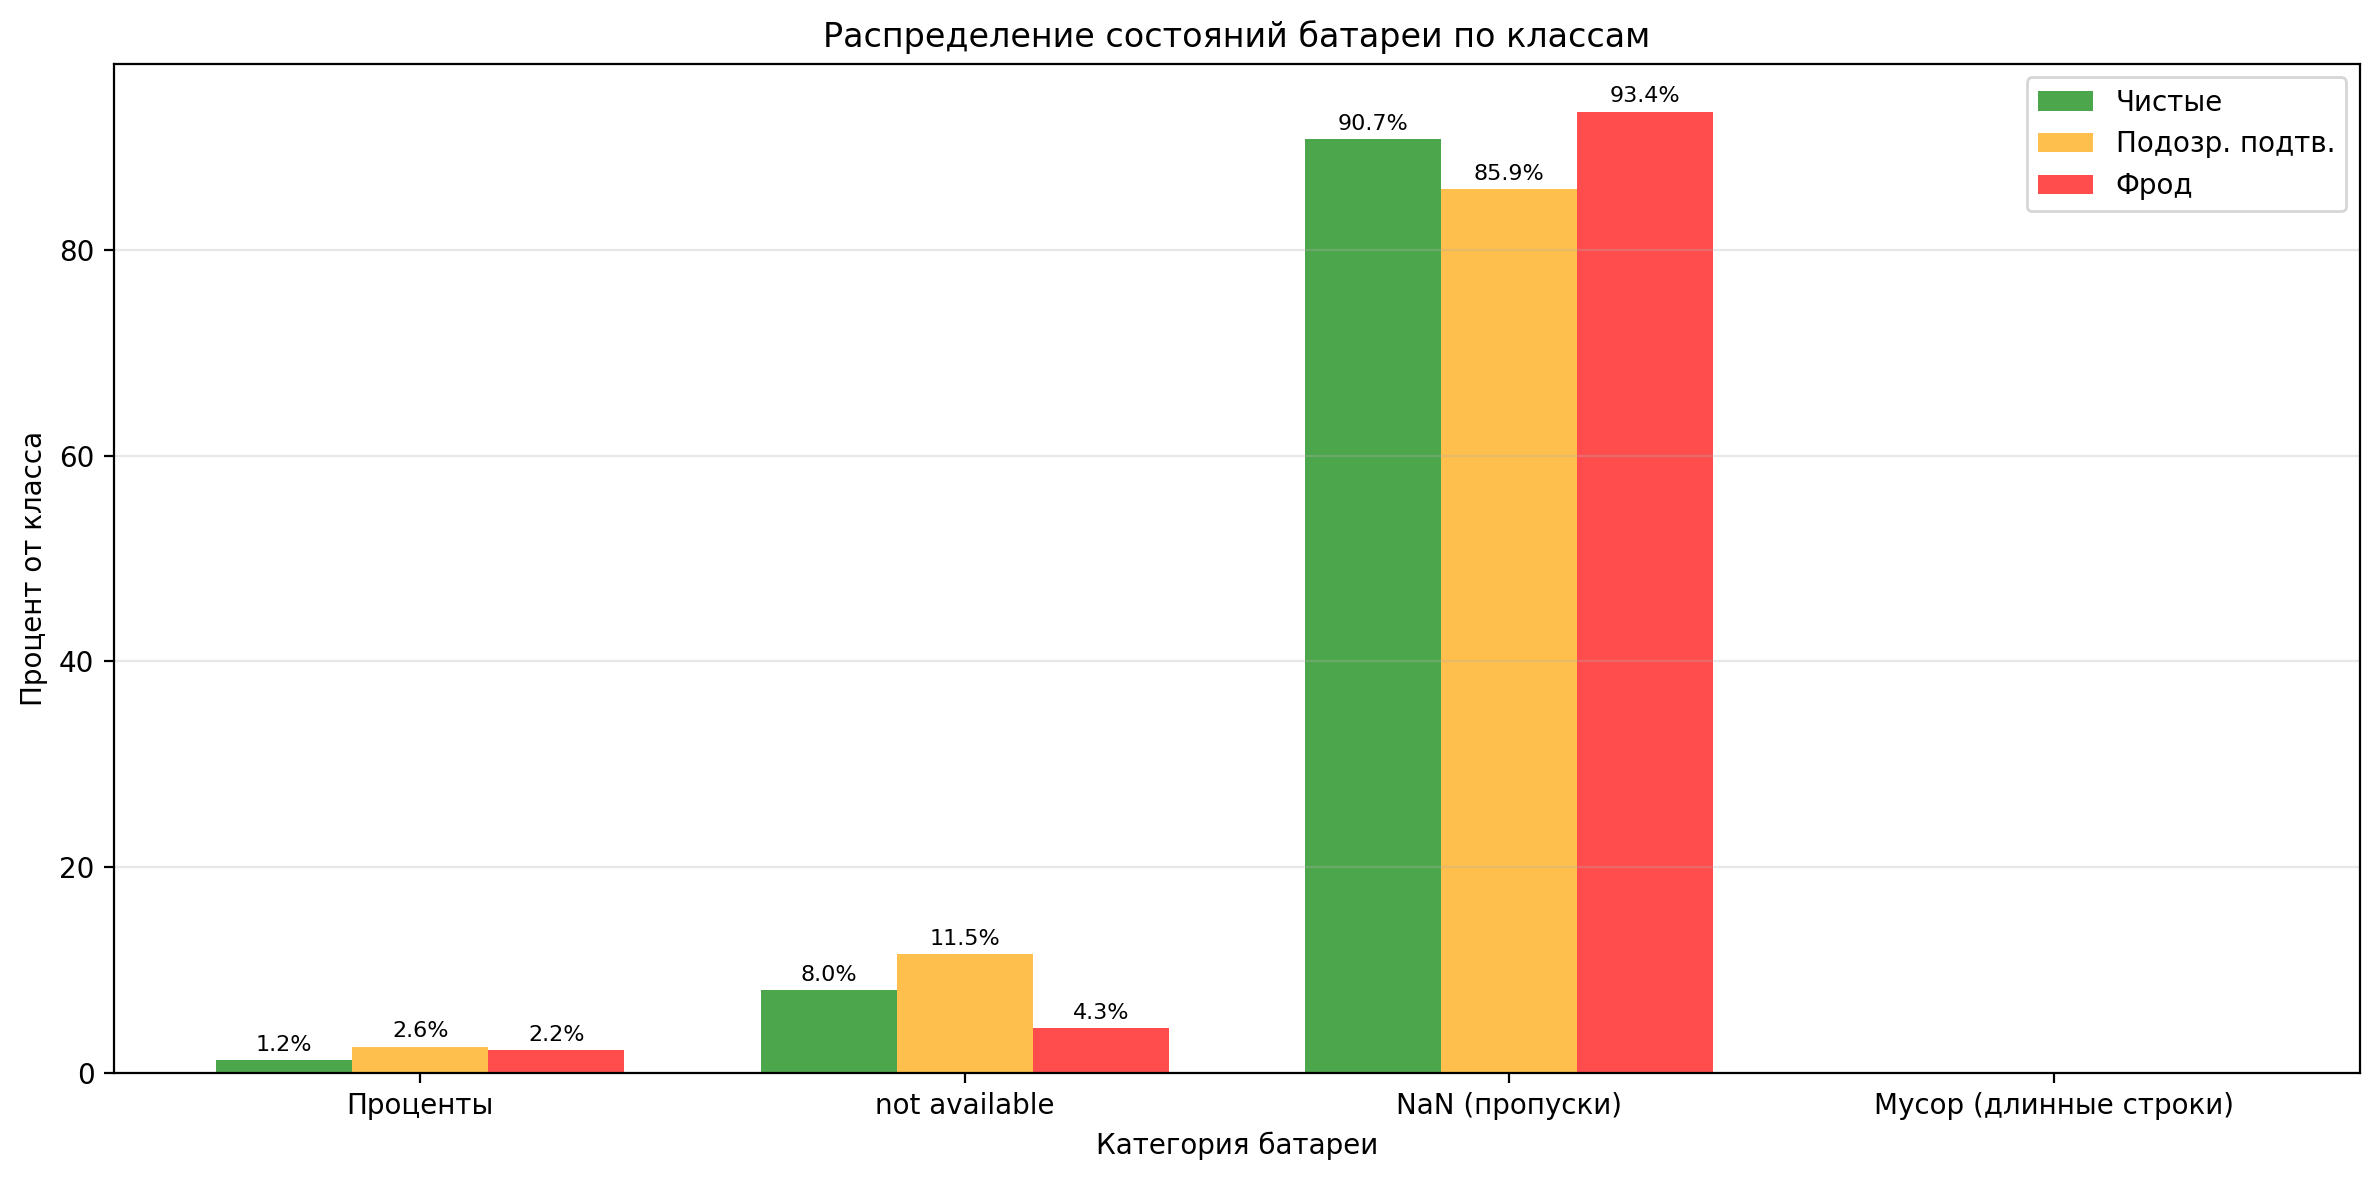

In [71]:
df_plot = train1_df.copy()

def get_battery_category(val):
    if pd.isna(val) or val == 'NaN%':
        return 'NaN (пропуски)'
    elif val == 'not available':
        return 'not available'
    elif isinstance(val, str) and val.endswith('%'):
        return 'Проценты'
    else:
        return 'Мусор (длинные строки)'

df_plot['battery_cat'] = df_plot['battery'].apply(get_battery_category)

total_dist = df_plot['battery_cat'].value_counts()
total_pct = df_plot['battery_cat'].value_counts(normalize=True) * 100

for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
    if cat in total_dist.index:
        print(f"  {cat}: {total_dist[cat]} ({total_pct[cat]:.10f}%)")
    else:
        print(f"  {cat}: 0 (0.0000000000%)")

class_dist = {}

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_plot[df_plot['target'] == target]
    dist = subset['battery_cat'].value_counts(normalize=True) * 100
    class_dist[name] = dist
    print(f"\n{name} (n = {len(subset)}):")
    for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
        if cat in dist.index:
            print(f"  {cat}: {dist[cat]:.2f}%")
        else:
            print(f"  {cat}: 0.0000000000%")

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']
x = np.arange(len(categories))
width = 0.25

values = []
for name in ['Чистые', 'Подозр. подтв.', 'Фрод']:
    values.append([class_dist[name].get(cat, 0) for cat in categories])

bars1 = ax.bar(x - width, values[0], width, label='Чистые', color='green', alpha=0.7)
bars2 = ax.bar(x, values[1], width, label='Подозр. подтв.', color='orange', alpha=0.7)
bars3 = ax.bar(x + width, values[2], width, label='Фрод', color='red', alpha=0.7)

ax.set_xlabel('Категория батареи')
ax.set_ylabel('Процент от класса')
ax.set_title('Распределение состояний батареи по классам')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 1:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Создадим 3 бинарных признака: имеется/не имеется заряд; батарея недоступна; мусор. Четвертое значение (NaN) будет отсутствием значений во всех признаках.  
Примерно так:

In [72]:
"""
df['battery_percent'] = (df['battery'].astype(str).str.endswith('%') & (df['battery'] != 'NaN%')).astype(int)
df['battery_not_available'] = (df['battery'] == 'not available').astype(int)
df['battery_garbage'] = (~df['battery'].isna() & 
                         ~df['battery'].astype(str).str.endswith('%') & 
                         (df['battery'] != 'not available') & 
                         (df['battery'] != 'NaN%')).astype(int)
"""

"\ndf['battery_percent'] = (df['battery'].astype(str).str.endswith('%') & (df['battery'] != 'NaN%')).astype(int)\ndf['battery_not_available'] = (df['battery'] == 'not available').astype(int)\ndf['battery_garbage'] = (~df['battery'].isna() & \n                         ~df['battery'].astype(str).str.endswith('%') & \n                         (df['battery'] != 'not available') & \n                         (df['battery'] != 'NaN%')).astype(int)\n"

#### event_type_nm

In [73]:
print(f"Тип данных: {train1_df['event_type_nm'].dtype}")
print(f"Уникальных значений: {train1_df['event_type_nm'].nunique()}")
print(f"Пропусков: {train1_df['event_type_nm'].isna().sum()}\n")
print(train1_df['event_type_nm'].value_counts())

print("\nРаспределение топ-5 типов по классам:")
top5 = train1_df['event_type_nm'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    type_dist = subset['event_type_nm'].value_counts(normalize=True).head(5) * 100
    for type_val, pct in type_dist.items():
        if type_val in top5:
            print(f"  Тип {type_val}: {pct:.2f}%")

Тип данных: int32
Уникальных значений: 17
Пропусков: 0

event_type_nm
7     11945911
14    11657184
8      2076315
9      1397391
11      771410
2       345056
3       246317
10       60974
6        28784
4        28206
0        19933
15       16205
16       14851
12        3917
5         3128
13        2982
1           30
Name: count, dtype: int64

Распределение топ-5 типов по классам:

Чистые:
  Тип 7: 41.75%
  Тип 14: 40.73%
  Тип 8: 7.25%
  Тип 9: 4.88%
  Тип 11: 2.70%

Подозр. подтв.:
  Тип 7: 35.13%
  Тип 14: 35.08%
  Тип 8: 11.09%
  Тип 9: 4.70%

Фрод:
  Тип 14: 45.40%
  Тип 7: 35.26%
  Тип 8: 5.67%
  Тип 9: 3.49%


#### event_desc

In [74]:
print(f"Тип данных: {train1_df['event_desc'].dtype}")
print(f"Уникальных значений: {train1_df['event_desc'].nunique()}")
print(f"Пропусков: {train1_df['event_desc'].isna().sum()}")

print("\nТоп-20 самых частых значений:")
print(train1_df['event_desc'].value_counts())

# 3. Статистика по классам
print("\nРаспределение топ-5 значений по классам:")
top5_desc = train1_df['event_desc'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    desc_dist = subset['event_desc'].value_counts(normalize=True).head(5) * 100
    for desc_val, pct in desc_dist.items():
        if desc_val in top5_desc:
            print(f"  {desc_val}: {pct:.2f}%")

print("\nСвязь с event_type_nm:")
desc_type_corr = train1_df.groupby(['event_desc', 'event_type_nm']).size().reset_index(name='count')
desc_type_corr = desc_type_corr.sort_values('count', ascending=False).head(10)
print(desc_type_corr)

Тип данных: int32
Уникальных значений: 143
Пропусков: 0

Топ-20 самых частых значений:
event_desc
56     11954067
75      7561725
36      1923232
86      1827518
48       767013
         ...   
157           1
156           1
127           1
142           1
161           1
Name: count, Length: 143, dtype: int64

Распределение топ-5 значений по классам:

Чистые:
  56: 41.78%
  75: 26.43%
  36: 6.72%
  86: 6.38%
  48: 2.68%

Подозр. подтв.:
  56: 35.56%
  75: 12.82%
  86: 10.37%
  36: 8.48%

Фрод:
  56: 35.30%
  75: 24.43%
  36: 5.52%
  86: 5.09%

Связь с event_type_nm:
     event_desc  event_type_nm     count
56           56              7  11945911
76           75             14   7561725
35           36             14   1923232
87           86              8   1827518
48           48             11    767013
100         101             14    500161
17           17              9    486345
36           37              9    387213
89           88              2    334959
49           49

#### channel_indicator_type

In [75]:
print(f"Тип данных: {train1_df['channel_indicator_type'].dtype}")
print(f"Уникальных значений: {train1_df['channel_indicator_type'].nunique()}")
print(f"Пропусков: {train1_df['channel_indicator_type'].isna().sum()}")

# 2. Распределение значений
print("\nРаспределение значений:")
print(train1_df['channel_indicator_type'].value_counts().head(10))

# 3. Распределение по классам
print("\nРаспределение топ-5 значений по классам:")
top5 = train1_df['channel_indicator_type'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    dist = subset['channel_indicator_type'].value_counts(normalize=True).head(5) * 100
    for val, pct in dist.items():
        if val in top5:
            print(f"  Тип {val}: {pct:.2f}%")

Тип данных: int32
Уникальных значений: 7
Пропусков: 0

Распределение значений:
channel_indicator_type
4    14769701
0     8298345
3     4782622
1      472826
6      175432
2      119476
5         192
Name: count, dtype: int64

Распределение топ-5 значений по классам:

Чистые:
  Тип 4: 51.61%
  Тип 0: 29.00%
  Тип 3: 16.71%
  Тип 1: 1.65%
  Тип 6: 0.61%

Подозр. подтв.:
  Тип 4: 55.88%
  Тип 3: 20.97%
  Тип 0: 20.95%
  Тип 1: 2.14%
  Тип 6: 0.05%

Фрод:
  Тип 4: 48.57%
  Тип 0: 34.22%
  Тип 3: 15.54%
  Тип 1: 1.44%
  Тип 6: 0.22%


#### channel_indicator_sub_type

In [76]:
print(f"Тип данных: {train1_df['channel_indicator_sub_type'].dtype}")
print(f"Уникальных значений: {train1_df['channel_indicator_sub_type'].nunique()}")
print(f"Пропусков: {train1_df['channel_indicator_sub_type'].isna().sum()}")

print("\nРаспределение значений:")
print(train1_df['channel_indicator_sub_type'].value_counts())

Тип данных: int32
Уникальных значений: 16
Пропусков: 0

Распределение значений:
channel_indicator_sub_type
15    14040044
5      8400832
4      4856311
14      889622
0       116800
16      116730
7        61078
12       55957
2        54085
11       19712
1         4706
3         1824
8          697
13         191
10           4
6            1
Name: count, dtype: int64


#### operaton_amt

In [77]:
print(f"Тип данных: {train1_df['operaton_amt'].dtype}")
print(f"Пропусков: {train1_df['operaton_amt'].isna().sum()}")

print("\nСтатистика по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]['operaton_amt']
    print(f"\n{name}:")
    print(f"  Среднее: {subset.mean():.2f}")
    print(f"  Медиана: {subset.median():.2f}")
    print(f"  Мин: {subset.min():.2f}")
    print(f"  Макс: {subset.max():.2f}")
    print(f"  25%: {subset.quantile(0.25):.2f}")
    print(f"  75%: {subset.quantile(0.75):.2f}")
    print(f"  95%: {subset.quantile(0.95):.2f}")
    print(f"  99%: {subset.quantile(0.99):.2f}")

Тип данных: float64
Пропусков: 13353367

Статистика по классам:

Чистые:
  Среднее: 2439305.71
  Медиана: 71137.00
  Мин: 0.00
  Макс: 276851690347.00
  25%: 24005.00
  75%: 277187.00
  95%: 3655313.60
  99%: 29943000.00

Подозр. подтв.:
  Среднее: 22885937.08
  Медиана: 1010000.00
  Мин: 0.00
  Макс: 12762880000.00
  25%: 75004.00
  75%: 16015352.00
  95%: 94875420.00
  99%: 259747398.38

Фрод:
  Среднее: 7042597.08
  Медиана: 362916.00
  Мин: 0.00
  Макс: 1150380064.00
  25%: 39766.00
  75%: 4993050.00
  95%: 31822743.00
  99%: 99650473.00


Видим, что в данных почти половина пропусков. Можно создать бинарный признак "сумма отсутствует". Сначала проверим, есть ли зависимость фрода и отсутствия суммы.

In [78]:
df_check = train1_df.copy()
df_check['amount_missing'] = df_check['operaton_amt'].isna().astype(int)

total_missing = df_check['amount_missing'].sum()
total_ops = len(df_check)
print(f"Всего операций без суммы: {total_missing} ({total_missing/total_ops*100:.2f}%)")

print("\nРаспределение пропусков по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_check[df_check['target'] == target]
    missing_pct = subset['amount_missing'].mean() * 100
    print(f"{name}: {missing_pct:.2f}% операций без суммы")

print("\nСостав операций без суммы:")
missing_ops = df_check[df_check['amount_missing'] == 1]
class_dist = missing_ops['target'].value_counts(normalize=True) * 100
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    if target in class_dist.index:
        print(f"{name}: {class_dist[target]:.2f}%")
    else:
        print(f"{name}: 0.00%")

print("\nСравнение с операциями, где сумма есть:")
ops_with_amount = df_check[df_check['amount_missing'] == 0]
class_dist_with = ops_with_amount['target'].value_counts(normalize=True) * 100
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    if target in class_dist_with.index:
        print(f"{name}: {class_dist_with[target]:.2f}%")
    else:
        print(f"{name}: 0.00%")

Всего операций без суммы: 13353367 (46.66%)

Распределение пропусков по классам:
Чистые: 46.66% операций без суммы
Подозр. подтв.: 45.35% операций без суммы
Фрод: 41.68% операций без суммы

Состав операций без суммы:
Чистые: 99.90%
Подозр. подтв.: 0.04%
Фрод: 0.05%

Сравнение с операциями, где сумма есть:
Чистые: 99.89%
Подозр. подтв.: 0.04%
Фрод: 0.07%


#### currency_iso_cd

In [79]:
print(f"Тип данных: {train1_df['currency_iso_cd'].dtype}")
print(f"Уникальных значений: {train1_df['currency_iso_cd'].nunique()}")
print(f"Пропусков: {train1_df['currency_iso_cd'].isna().sum()}")

print("\nРаспределение валют:")
currency_dist = train1_df['currency_iso_cd'].value_counts()
for curr, count in currency_dist.head(10).items():
    pct = count / len(train1_df) * 100
    print(f"  {curr}: {count} ({pct:.2f}%)")

print("\nРаспределение топ-5 валют по классам:")
top5_currency = train1_df['currency_iso_cd'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    curr_dist = subset['currency_iso_cd'].value_counts(normalize=True).head(5) * 100
    for curr, pct in curr_dist.items():
        if curr in top5_currency:
            print(f"  Валюта {curr}: {pct:.2f}%")

Тип данных: float64
Уникальных значений: 19
Пропусков: 12996950

Распределение валют:
  0.0: 15604232 (54.52%)
  7.0: 10468 (0.04%)
  8.0: 5156 (0.02%)
  2.0: 519 (0.00%)
  6.0: 333 (0.00%)
  1.0: 298 (0.00%)
  5.0: 246 (0.00%)
  3.0: 189 (0.00%)
  4.0: 117 (0.00%)
  17.0: 19 (0.00%)

Распределение топ-5 валют по классам:

Чистые:
  Валюта 0.0: 99.89%
  Валюта 7.0: 0.07%
  Валюта 8.0: 0.03%
  Валюта 2.0: 0.00%
  Валюта 6.0: 0.00%

Подозр. подтв.:
  Валюта 0.0: 99.72%
  Валюта 2.0: 0.17%
  Валюта 8.0: 0.06%
  Валюта 7.0: 0.03%
  Валюта 6.0: 0.01%

Фрод:
  Валюта 0.0: 99.96%
  Валюта 8.0: 0.04%


#### mcc_code

In [80]:
print(f"Тип данных: {train1_df['mcc_code'].dtype}")
print(f"Уникальных значений: {train1_df['mcc_code'].nunique()}")
print(f"Пропусков: {train1_df['mcc_code'].isna().sum()}\n")

print(train1_df['mcc_code'].value_counts())


print("\nРаспределение топ-5 MCC по классам:")
top5_mcc = train1_df['mcc_code'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    mcc_dist = subset['mcc_code'].value_counts(normalize=True).head(5) * 100
    for mcc, pct in mcc_dist.items():
        if mcc in top5_mcc:
            print(f"  MCC {mcc}: {pct:.2f}%")
        else:
            print(f"  MCC {mcc}: {pct:.2f}% (не в топ-5)")

Тип данных: str
Уникальных значений: 20
Пропусков: 20440094

mcc_code
4     3804765
10     899120
15     781895
17     649169
9      358092
1      323720
19     321235
7      248855
14     211199
16     180184
18      90616
2       89472
3       80808
0       29521
13      25565
6       24425
11      18818
8       15578
5       13506
12      11957
Name: count, dtype: int64

Распределение топ-5 MCC по классам:

Чистые:
  MCC 4: 46.55%
  MCC 10: 10.97%
  MCC 15: 9.56%
  MCC 17: 7.94%
  MCC 9: 4.38%

Подозр. подтв.:
  MCC 10: 39.48%
  MCC 4: 28.57%
  MCC 15: 6.67%
  MCC 17: 5.86%
  MCC 9: 3.22%

Фрод:
  MCC 10: 34.33%
  MCC 16: 25.50% (не в топ-5)
  MCC 4: 12.71%
  MCC 19: 6.16% (не в топ-5)
  MCC 3: 5.41% (не в топ-5)


#### pos_cd

In [81]:
print(f"Тип данных: {train1_df['pos_cd'].dtype}")
print(f"Уникальных значений: {train1_df['pos_cd'].nunique()}")
print(f"Пропусков: {train1_df['pos_cd'].isna().sum()}\n")

print(train1_df['pos_cd'].value_counts())

print("\nРаспределение топ-5 POS по классам:")
top5_pos = train1_df['pos_cd'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    pos_dist = subset['pos_cd'].value_counts(normalize=True).head(5) * 100
    for pos, pct in pos_dist.items():
        if pos in top5_pos:
            print(f"  POS {pos}: {pct:.2f}%")
        else:
            print(f"  POS {pos}: {pct:.2f}% (не в топ-5)")

Тип данных: float64
Уникальных значений: 22
Пропусков: 26134680

pos_cd
3.000     1634195
1.000      749494
14.000      33381
8.000       30394
10.000      17454
9.000        7966
4.000        6027
16.000       2342
11.000        872
2.000         726
12.000        317
13.000        217
7.000         170
5.000         114
17.000         77
19.000         75
0.000          57
6.000          18
18.000         13
15.000          3
23.000          1
20.000          1
Name: count, dtype: int64

Распределение топ-5 POS по классам:

Чистые:
  POS 3.0: 65.83%
  POS 1.0: 30.14%
  POS 14.0: 1.34%
  POS 8.0: 1.22%
  POS 10.0: 0.70%

Подозр. подтв.:
  POS 3.0: 76.94%
  POS 1.0: 19.29%
  POS 14.0: 1.69%
  POS 8.0: 0.61%
  POS 10.0: 0.61%

Фрод:
  POS 1.0: 62.39%
  POS 3.0: 34.44%
  POS 10.0: 1.29%
  POS 8.0: 0.93%
  POS 4.0: 0.42% (не в топ-5)


#### accept_language

In [82]:
print(f"Тип данных: {train1_df['accept_language'].dtype}")
print(f"Уникальных значений: {train1_df['accept_language'].nunique()}")
print(f"Пропусков: {train1_df['accept_language'].isna().sum()}")

print("\nТоп-20 самых частых значений:")
print(train1_df['accept_language'].value_counts().head(30))

print("\nСлужебные значения:")
special_vals = ['not available', 'unknown', 'none', 'null', 'NULL']
for val in special_vals:
    count = train1_df[train1_df['accept_language'] == val].shape[0]
    if count > 0:
        print(f"  {val}: {count}")


print("\nРаспределение топ-5 языков по классам:")
top5_lang = train1_df['accept_language'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    lang_dist = subset['accept_language'].value_counts(normalize=True).head(5) * 100
    for lang, pct in lang_dist.items():
        if lang in top5_lang:
            print(f"  {lang}: {pct:.2f}%")

Тип данных: str
Уникальных значений: 374
Пропусков: 25452822

Топ-20 самых частых значений:
accept_language
ru                                                          2596882
ru-ru                                                        361905
ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7                          133580
ru,en;q=0.9                                                   16963
en-gb                                                         12210
en-GB,en;q=0.9                                                10085
ru-RU,ru;q=0.8,en-US;q=0.5,en;q=0.3                            4926
*                                                              3234
en-us                                                          3073
ru,en;q=0.9,en-GB;q=0.8,en-US;q=0.7                            2546
en-US,en;q=0.9                                                 2448
en-GB,en-US;q=0.9,en;q=0.8                                      943
ru-RU,ru;q=0.9                                                  846
zh-CN,zh

#### browser language

In [89]:
print(f"Тип данных: {train1_df['browser_language'].dtype}")
print(f"Уникальных значений: {train1_df['browser_language'].nunique()}")
print(f"Пропусков: {train1_df['browser_language'].isna().sum()}")

print("\nТоп-5 самых частых значений:")
print(train1_df['browser_language'].value_counts().head(5))

Тип данных: str
Уникальных значений: 21
Пропусков: 25968210

Топ-5 самых частых значений:
browser_language
not available                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [83]:
total = len(train1_df)
missing = train1_df['browser_language'].isna().sum()
not_avail = (train1_df['browser_language'] == 'not available').sum()
long = (~train1_df['browser_language'].isna()) & (train1_df['browser_language'] != 'not available')

print(f"Всего: {total}")
print(f"Пропуски: {missing} ({missing/total*100:.2f}%)")
print(f"not available: {not_avail} ({not_avail/total*100:.2f}%)") 
print(f"Длинные строки: {long.sum()} ({long.sum()/total*100:.4f}%)")

Всего: 28618594
Пропуски: 25968210 (90.74%)
not available: 2650358 (9.26%)
Длинные строки: 26 (0.0001%)


Видим, что почти все значения в колонке - пропуски. Небольшая часть - not available. И всего 26 (0.0001%) - технические значения.  
Если в этих 26 есть фрод, колонка может быть полезной.

In [86]:
long_strings = train1_df[~train1_df['browser_language'].isna() & 
                  (train1_df['browser_language'] != 'not available')]

print(f"Всего длинных строк: {len(long_strings)}")

print("\nРаспределение по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр/подтв'), (1, 'Фрод')]:
    count = len(long_strings[long_strings['target'] == target])
    print(f"{name}: {count}")

Всего длинных строк: 26

Распределение по классам:
Чистые: 26
Подозр/подтв: 0
Фрод: 0


В 26 уникальных значениях не содержится фрода -> удаляем признак.